In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader

In [2]:
import os
from pathlib import Path

# Temperature to inspect
temperature = 40


def resolve_tensorboard_dir(temperature: int) -> Path:
    """Locate the tensorboard directory from either the repo root or saved_datas."""
    cwd = Path.cwd().resolve()
    candidates = []

    for base in (cwd, *cwd.parents):
        candidates.append(base / "saved_datas" / "overhauled_train" / f"T{temperature}" / "tensorboard" )

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique_candidates.append(resolved)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate

    searched_paths = "\n".join(f"  - {candidate}" for candidate in unique_candidates)
    raise FileNotFoundError(
        f"Could not find tensorboard logs for T{temperature}. Searched:\n{searched_paths}"
    )


log_dir = resolve_tensorboard_dir(temperature)
print(f"Using log_dir: {log_dir}")

# Leave empty to analyze all runs, or set explicitly like ['PPO_1']
custom_runs = ["PPO_2",]

# List all available runs
all_runs = sorted(
    d.name for d in log_dir.iterdir()
    if d.is_dir()
)

print(f'All available runs ({len(all_runs)}):')
for run in all_runs:
    print(f'  - {run}')

# Filter runs based on custom selection
if custom_runs:
    runs_to_analyze = []
    for run in custom_runs:
        if run in all_runs:
            runs_to_analyze.append(run)
        else:
            print(f'Warning: Run {run} not found in available runs')
else:
    runs_to_analyze = all_runs.copy()

print(f'\nRuns to analyze ({len(runs_to_analyze)}):')
for run in runs_to_analyze:
    print(f'  - {run}')

Using log_dir: /home/yanli/xuanyanma/SwiftChargingProtocol/saved_datas/overhauled_train/T40/tensorboard
All available runs (2):
  - PPO_1
  - PPO_2

Runs to analyze (1):
  - PPO_2


In [3]:
# Load event files for selected runs
event_files = {}
for run in runs_to_analyze:
    run_dir = os.path.join(log_dir, run)
    event_file = None
    for f in os.listdir(run_dir):
        if f.startswith('events.out.tfevents'):
            event_file = os.path.join(run_dir, f)
            break
    if event_file:
        event_files[run] = event_file
        print(f'Loaded event file for {run}: {event_file}')
        print(f'File size: {os.path.getsize(event_file) / 1024:.2f} KB')
    else:
        print(f'No event file found for {run}')

Loaded event file for PPO_2: /home/yanli/xuanyanma/SwiftChargingProtocol/saved_datas/overhauled_train/T40/tensorboard/PPO_2/events.out.tfevents.1777614387.c10.52936.0
File size: 2453.89 KB


In [4]:
# Debug: Inspect event file content
def debug_event_file(event_file):
    print(f'=== Debugging event file: {event_file} ===')
    try:
        # Try EventAccumulator first
        event_acc = EventAccumulator(event_file)
        event_acc.Reload()
        
        print('EventAccumulator tags:')
        print(f'  Scalars: {event_acc.Tags().get("scalars", [])}')
        print(f'  Histograms: {event_acc.Tags().get("histograms", [])}')
        print(f'  Images: {event_acc.Tags().get("images", [])}')
        print(f'  Audio: {event_acc.Tags().get("audio", [])}')
        print(f'  Tensors: {event_acc.Tags().get("tensors", [])}')
        
        # Try direct event iteration
        print('Trying direct event iteration:')
        loader = EventFileLoader(event_file)
        event_count = 0
        for event in loader.Load():
            event_count += 1
            if event_count <= 10:  # Show first 10 events
                print(f'  Event {event_count}: type={event.WhichOneof("what")}, step={event.step}, wall_time={event.wall_time}')
        print(f'  Total events: {event_count}')
        
    except Exception as e:
        print(f'Error debugging event file: {e}')
        import traceback
        traceback.print_exc()

# Debug all event files
for run, event_file in event_files.items():
    debug_event_file(event_file)

=== Debugging event file: /home/yanli/xuanyanma/SwiftChargingProtocol/saved_datas/overhauled_train/T40/tensorboard/PPO_2/events.out.tfevents.1777614387.c10.52936.0 ===
EventAccumulator tags:
  Scalars: ['envs/env_0/avg_temp_c', 'envs/env_0/charge_time_s1', 'envs/env_0/charge_time_s2', 'envs/env_0/charge_time_s3', 'envs/env_0/charge_time_s_total', 'envs/env_0/chargerate1_c', 'envs/env_0/chargerate2_c', 'envs/env_0/cycle', 'envs/env_0/delta_soh', 'envs/env_0/discharge_capacity_ah', 'envs/env_0/lam_neg', 'envs/env_0/lam_pos', 'envs/env_0/lli', 'envs/env_0/reward_soh', 'envs/env_0/reward_time', 'envs/env_0/reward_total', 'envs/env_0/soh_measured', 'envs/env_0/terminal_current_c', 'envs/env_0/throughput_ah', 'envs/env_1/avg_temp_c', 'envs/env_1/charge_time_s1', 'envs/env_1/charge_time_s2', 'envs/env_1/charge_time_s3', 'envs/env_1/charge_time_s_total', 'envs/env_1/chargerate1_c', 'envs/env_1/chargerate2_c', 'envs/env_1/cycle', 'envs/env_1/delta_soh', 'envs/env_1/discharge_capacity_ah', 'envs

In [5]:
# Extract scalars from tensorboard logs
def extract_scalars(event_file):
    event_acc = EventAccumulator(event_file, size_guidance={
        'scalars': 0,  # 0 means load all
    })
    event_acc.Reload()
    
    scalars = {}
    for tag in event_acc.Tags()['scalars']:
        events = event_acc.Scalars(tag)
        steps = [event.step for event in events]
        values = [event.value for event in events]
        scalars[tag] = {'steps': steps, 'values': values}
    
    return scalars

# Extract scalars for selected runs
all_scalars = {}
for run, event_file in event_files.items():
    try:
        scalars = extract_scalars(event_file)
        all_scalars[run] = scalars
        print(f'Extracted {len(scalars)} scalars for {run}')
        if scalars:
            print(f'  Tags: {list(scalars.keys())}')
    except Exception as e:
        print(f'Error extracting scalars for {run}: {e}')
        import traceback
        traceback.print_exc()

Extracted 314 scalars for PPO_2
  Tags: ['envs/env_0/avg_temp_c', 'envs/env_0/charge_time_s1', 'envs/env_0/charge_time_s2', 'envs/env_0/charge_time_s3', 'envs/env_0/charge_time_s_total', 'envs/env_0/chargerate1_c', 'envs/env_0/chargerate2_c', 'envs/env_0/cycle', 'envs/env_0/delta_soh', 'envs/env_0/discharge_capacity_ah', 'envs/env_0/lam_neg', 'envs/env_0/lam_pos', 'envs/env_0/lli', 'envs/env_0/reward_soh', 'envs/env_0/reward_time', 'envs/env_0/reward_total', 'envs/env_0/soh_measured', 'envs/env_0/terminal_current_c', 'envs/env_0/throughput_ah', 'envs/env_1/avg_temp_c', 'envs/env_1/charge_time_s1', 'envs/env_1/charge_time_s2', 'envs/env_1/charge_time_s3', 'envs/env_1/charge_time_s_total', 'envs/env_1/chargerate1_c', 'envs/env_1/chargerate2_c', 'envs/env_1/cycle', 'envs/env_1/delta_soh', 'envs/env_1/discharge_capacity_ah', 'envs/env_1/lam_neg', 'envs/env_1/lam_pos', 'envs/env_1/lli', 'envs/env_1/reward_soh', 'envs/env_1/reward_time', 'envs/env_1/reward_total', 'envs/env_1/soh_measured', 

In [6]:
# Show all available scalar tags
if all_scalars:
    sample_run = list(all_scalars.keys())[0]
    tags = list(all_scalars[sample_run].keys())
    print(f'Available scalar tags in {sample_run}:')
    for tag in tags:
        print(f'  - {tag}')

Available scalar tags in PPO_2:
  - envs/env_0/avg_temp_c
  - envs/env_0/charge_time_s1
  - envs/env_0/charge_time_s2
  - envs/env_0/charge_time_s3
  - envs/env_0/charge_time_s_total
  - envs/env_0/chargerate1_c
  - envs/env_0/chargerate2_c
  - envs/env_0/cycle
  - envs/env_0/delta_soh
  - envs/env_0/discharge_capacity_ah
  - envs/env_0/lam_neg
  - envs/env_0/lam_pos
  - envs/env_0/lli
  - envs/env_0/reward_soh
  - envs/env_0/reward_time
  - envs/env_0/reward_total
  - envs/env_0/soh_measured
  - envs/env_0/terminal_current_c
  - envs/env_0/throughput_ah
  - envs/env_1/avg_temp_c
  - envs/env_1/charge_time_s1
  - envs/env_1/charge_time_s2
  - envs/env_1/charge_time_s3
  - envs/env_1/charge_time_s_total
  - envs/env_1/chargerate1_c
  - envs/env_1/chargerate2_c
  - envs/env_1/cycle
  - envs/env_1/delta_soh
  - envs/env_1/discharge_capacity_ah
  - envs/env_1/lam_neg
  - envs/env_1/lam_pos
  - envs/env_1/lli
  - envs/env_1/reward_soh
  - envs/env_1/reward_time
  - envs/env_1/reward_total
 

In [7]:
# Define the metrics to plot separately from the plotting logic
metrics_to_plot = [
    ('train/value_loss', 'Value Loss'),
    ('train/policy_gradient_loss', 'Policy Gradient Loss'),
    ('train/approx_kl', 'Approximate KL Divergence'),
    ('train/clip_fraction', 'Clip Fraction'),
    ('train/entropy_loss', 'Entropy Loss'),
    ('train/explained_variance', 'Explained Variance'),
    ('train/loss', 'Total Loss'),
    ('train/learning_rate', 'Learning Rate'),
    #('envs/env_0/reward_soh', 'SOH Reward'),
    #('envs/env_0/reward_time', 'Time Reward'),
    #('envs/env_0/reward_total', 'Total Reward'),
    #('envs/env_0/delta_soh', 'delta_soh'),
    #('envs/env_0/charge_time_s_total', 'Total Charge Time'),
    #('envs/env_0/soh_measured', 'Measured SOH'),
]

smoothing_window = 1


In [8]:
# 打印每个 metric 将要绘制的数据点数
for tag, title in metrics_to_plot:
    print(f"Metric: {title} ({tag})")
    for run, scalars in all_scalars.items():
        if tag in scalars:
            n_points = len(scalars[tag]['values'])
            print(f"  - Run {run}: {n_points} points")
        else:
            print(f"  - Run {run}: Tag not found")


Metric: Value Loss (train/value_loss)
  - Run PPO_2: 127 points
Metric: Policy Gradient Loss (train/policy_gradient_loss)
  - Run PPO_2: 127 points
Metric: Approximate KL Divergence (train/approx_kl)
  - Run PPO_2: 127 points
Metric: Clip Fraction (train/clip_fraction)
  - Run PPO_2: 127 points
Metric: Entropy Loss (train/entropy_loss)
  - Run PPO_2: 127 points
Metric: Explained Variance (train/explained_variance)
  - Run PPO_2: 127 points
Metric: Total Loss (train/loss)
  - Run PPO_2: 127 points
Metric: Learning Rate (train/learning_rate)
  - Run PPO_2: 127 points


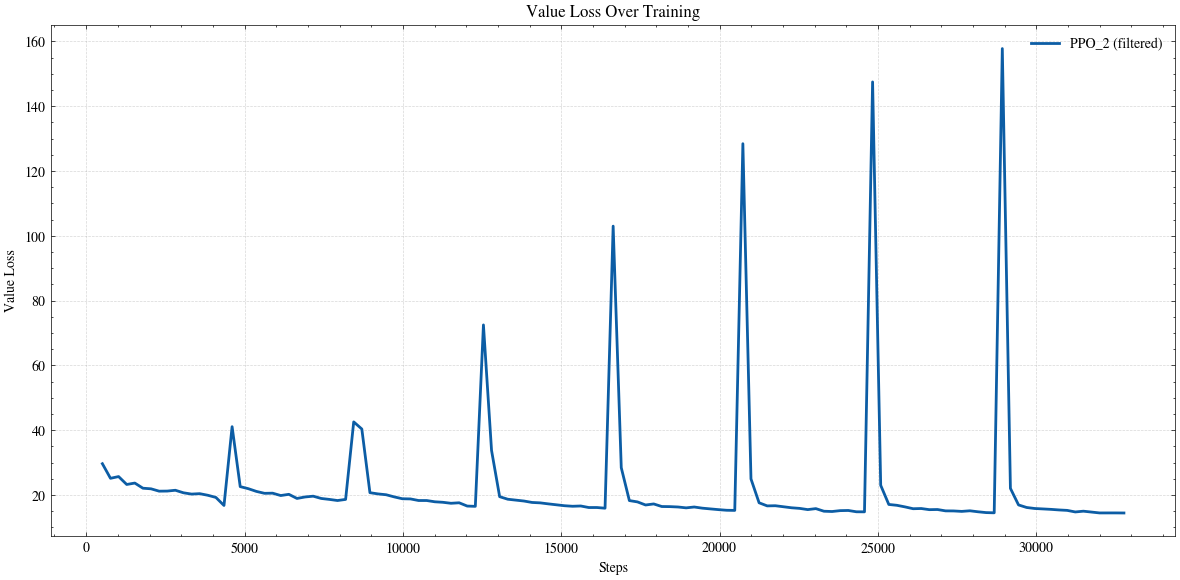

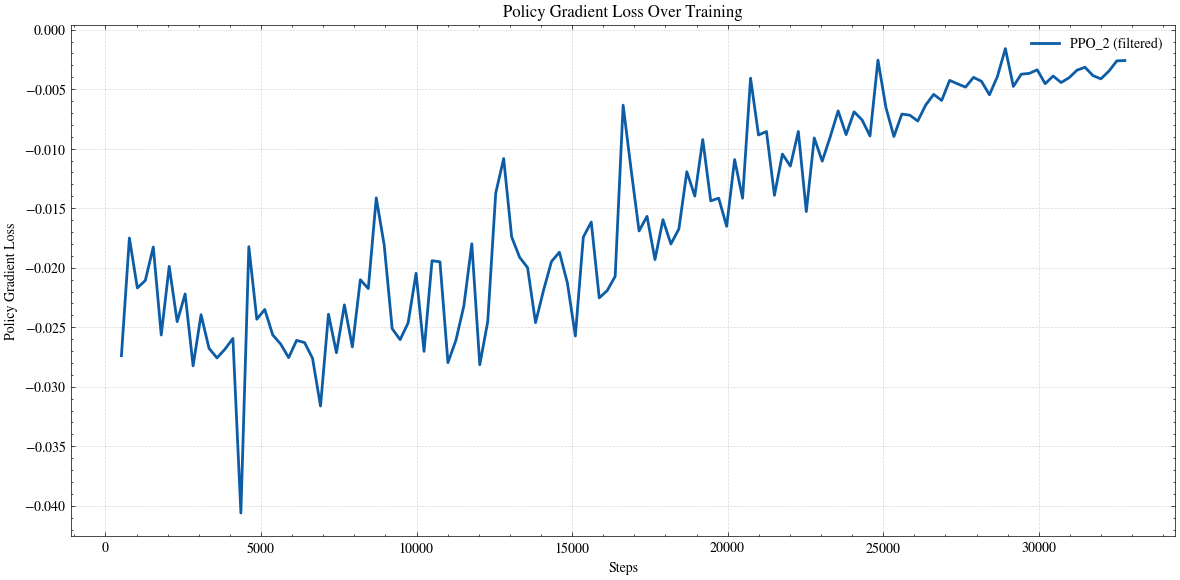

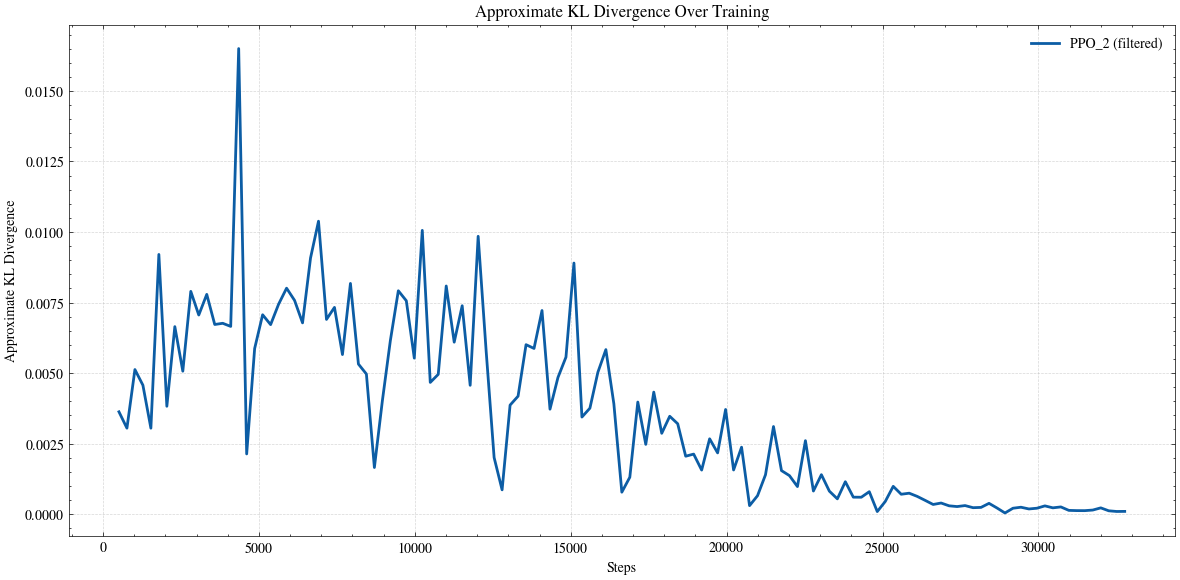

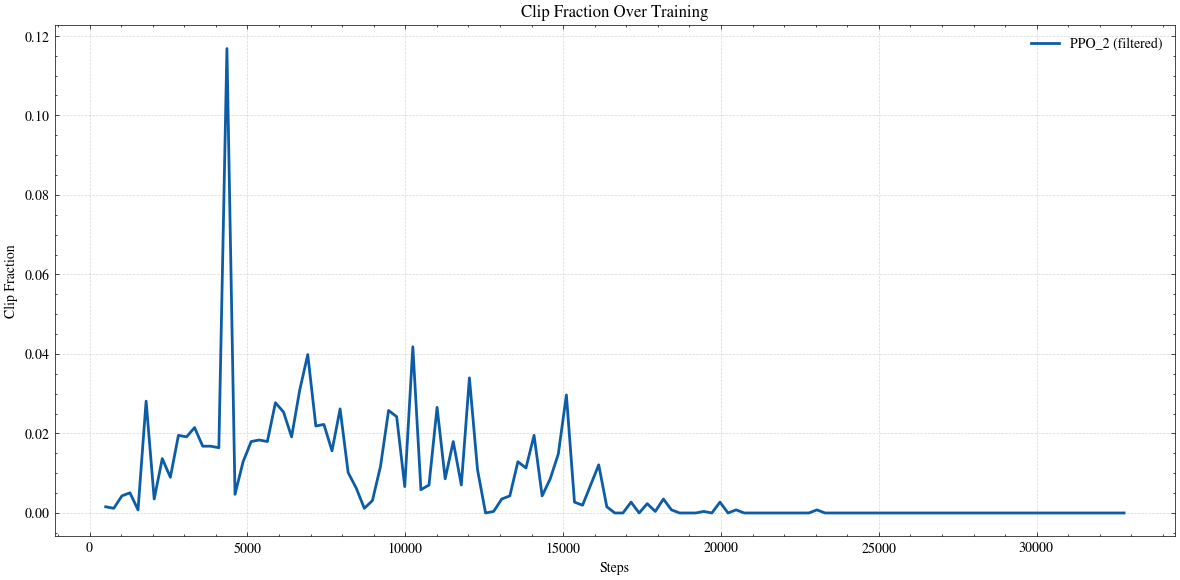

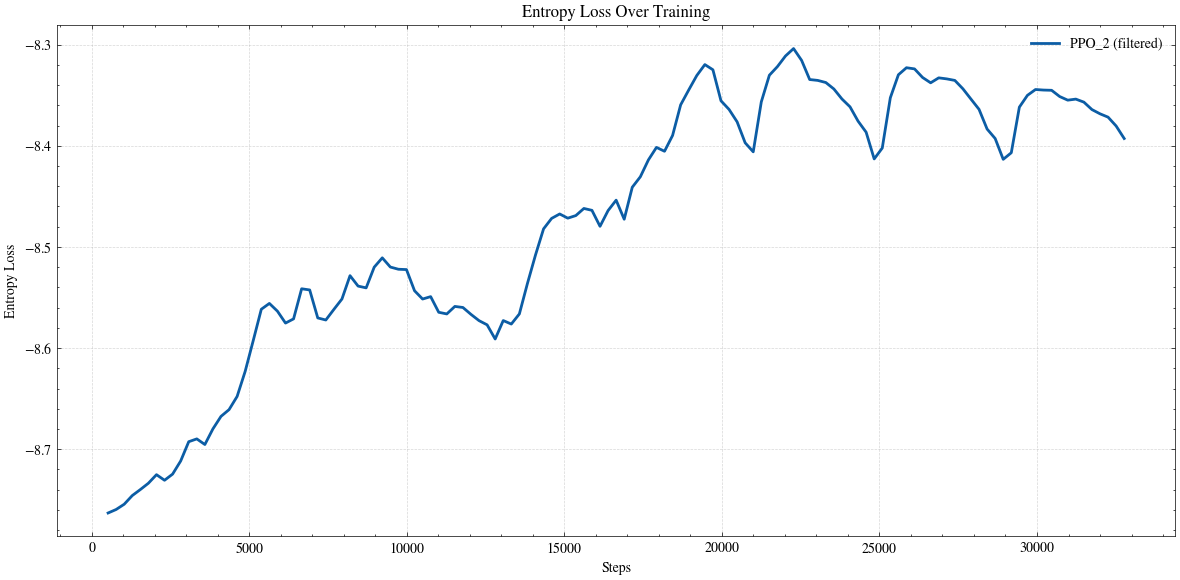

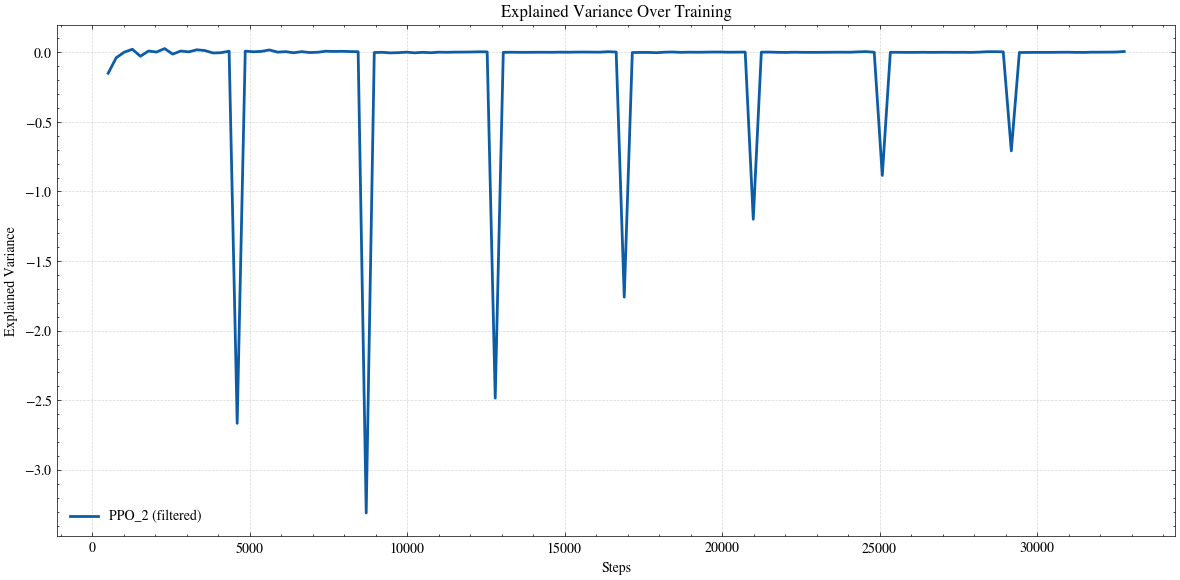

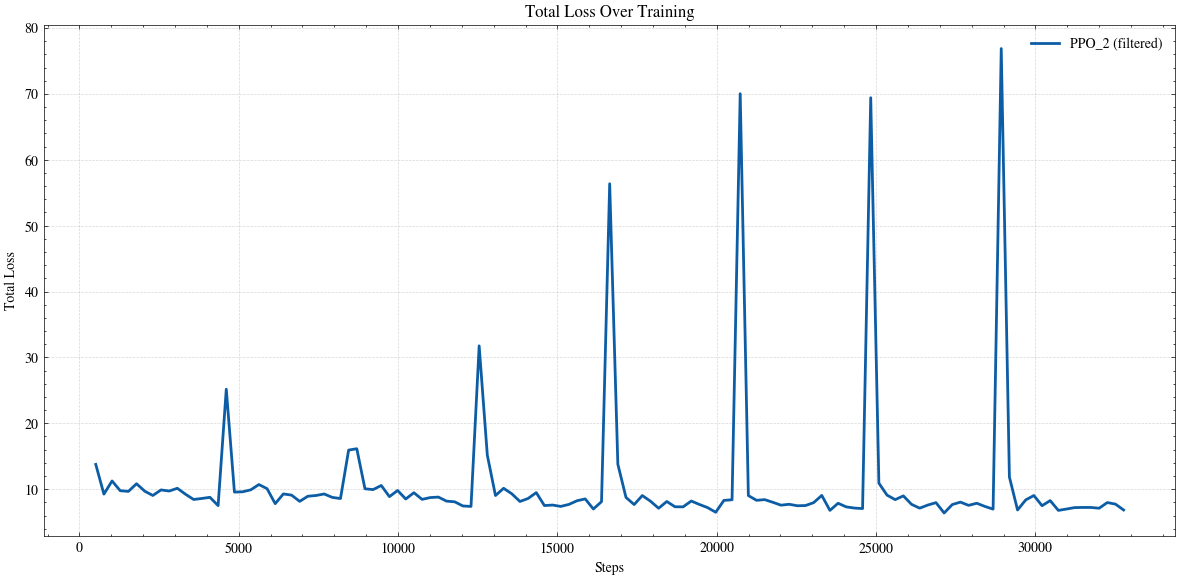

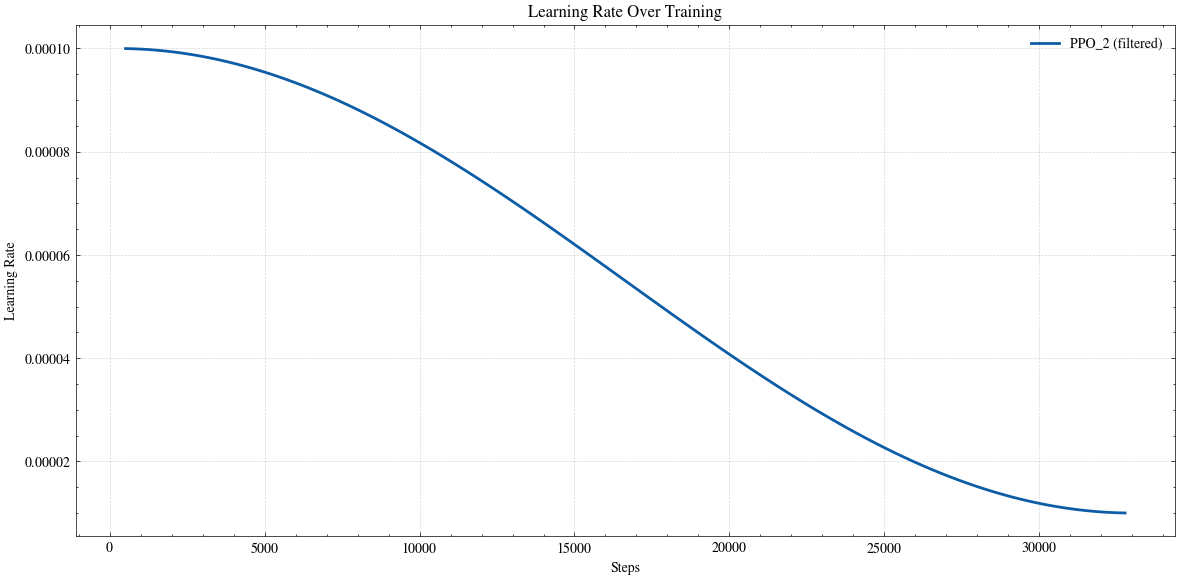

In [9]:
# Plot filtered metrics with SciencePlots styling
import scienceplots
plt.style.use(["science", "no-latex"])


def smooth_series(values, window):
    values = np.asarray(values, dtype=float)
    if values.size < 3:
        return values

    window = min(window, values.size if values.size % 2 == 1 else values.size - 1)
    if window < 3:
        return values
    if window % 2 == 0:
        window -= 1

    kernel = np.ones(window, dtype=float) / window
    pad = window // 2
    padded = np.pad(values, (pad, pad), mode='edge')
    return np.convolve(padded, kernel, mode='valid')

for tag, title in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    plotted = False

    for run, scalars in all_scalars.items():
        if tag in scalars:
            steps = scalars[tag]['steps']
            values = scalars[tag]['values']
            filtered_values = smooth_series(values, smoothing_window)
            plt.plot(steps, filtered_values, label=f"{run} (filtered)", linewidth=2)
            plotted = True

    if not plotted:
        plt.close()
        continue

    plt.xlabel('Steps')
    plt.ylabel(title)
    plt.title(title + ' Over Training')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


Found delta tags: ['envs/env_0/delta_soh', 'envs/env_1/delta_soh', 'envs/env_10/delta_soh', 'envs/env_11/delta_soh', 'envs/env_12/delta_soh', 'envs/env_13/delta_soh', 'envs/env_14/delta_soh', 'envs/env_15/delta_soh', 'envs/env_2/delta_soh', 'envs/env_3/delta_soh', 'envs/env_4/delta_soh', 'envs/env_5/delta_soh', 'envs/env_6/delta_soh', 'envs/env_7/delta_soh', 'envs/env_8/delta_soh', 'envs/env_9/delta_soh']
Found charge tags: ['envs/env_0/charge_time_s_total', 'envs/env_1/charge_time_s_total', 'envs/env_10/charge_time_s_total', 'envs/env_11/charge_time_s_total', 'envs/env_12/charge_time_s_total', 'envs/env_13/charge_time_s_total', 'envs/env_14/charge_time_s_total', 'envs/env_15/charge_time_s_total', 'envs/env_2/charge_time_s_total', 'envs/env_3/charge_time_s_total', 'envs/env_4/charge_time_s_total', 'envs/env_5/charge_time_s_total', 'envs/env_6/charge_time_s_total', 'envs/env_7/charge_time_s_total', 'envs/env_8/charge_time_s_total', 'envs/env_9/charge_time_s_total']
Found reward tags: ['

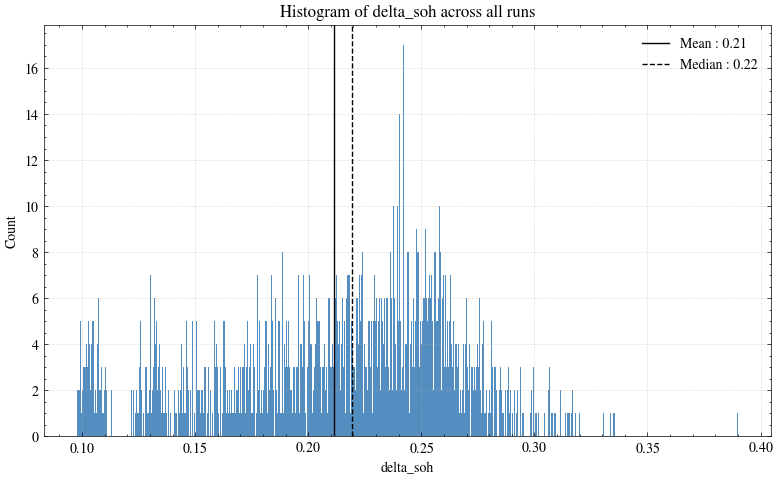

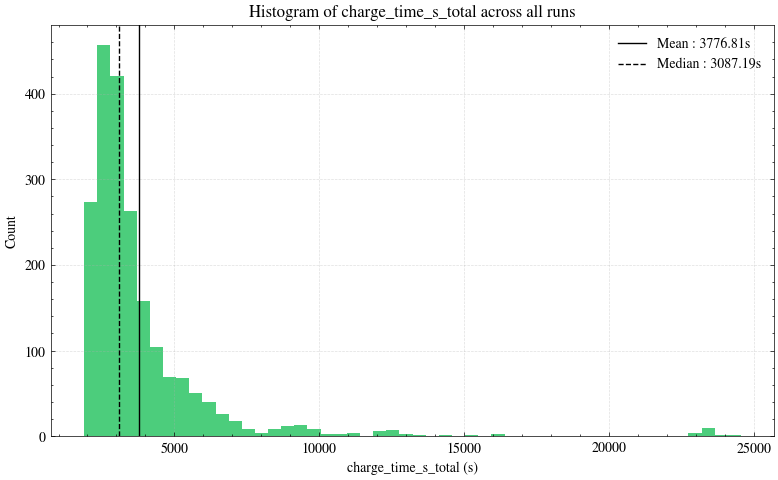

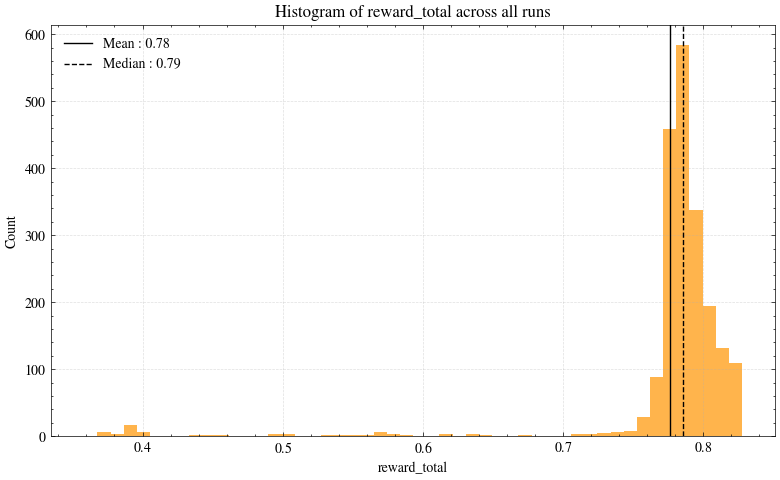

In [10]:
# Histograms for delta_soh, charge_time_s_total, and reward_total across all runs/environments
# This cell collects any tags containing 'delta_soh', 'charge_time_s_total', and 'reward_total' across runs
delta_key_frag = 'delta_soh'
charge_key_frag = 'charge_time_s_total'
reward_key_frag = 'reward_total'

# discover tags present in the loaded scalars
delta_tags = sorted({tag for scalars in all_scalars.values() for tag in scalars.keys() if delta_key_frag in tag})
charge_tags = sorted({tag for scalars in all_scalars.values() for tag in scalars.keys() if charge_key_frag in tag})
reward_tags = sorted({tag for scalars in all_scalars.values() for tag in scalars.keys() if reward_key_frag in tag})

print(f'Found delta tags: {delta_tags}')
print(f'Found charge tags: {charge_tags}')
print(f'Found reward tags: {reward_tags}')

# collect all values across runs for the discovered tags
delta_vals = []
for run, scalars in all_scalars.items():
    for tag in delta_tags:
        if tag in scalars:
            delta_vals.extend(scalars[tag]['values'])

charge_vals = []
for run, scalars in all_scalars.items():
    for tag in charge_tags:
        if tag in scalars:
            charge_vals.extend(scalars[tag]['values'])

reward_vals = []
for run, scalars in all_scalars.items():
    for tag in reward_tags:
        if tag in scalars:
            reward_vals.extend(scalars[tag]['values'])

import numpy as _np
delta_arr = _np.asarray(delta_vals, dtype=float)  # convert to percentage
charge_arr = _np.asarray(charge_vals, dtype=float)
reward_arr = _np.asarray(reward_vals, dtype=float)

# drop non-finite entries
delta_arr = delta_arr[_np.isfinite(delta_arr)]
charge_arr = charge_arr[_np.isfinite(charge_arr)]
reward_arr = reward_arr[_np.isfinite(reward_arr)]

if delta_arr.size == 0 and charge_arr.size == 0 and reward_arr.size == 0:
    print('No data found for delta_soh, charge_time_s_total, or reward_total across runs.')
else:
    if delta_arr.size > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(delta_arr, bins=1000, color='C0', alpha=0.7)
        plt.title('Histogram of delta_soh across all runs')
        plt.xlabel('delta_soh')
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', alpha=0.4)
        delta_arr_mean = _np.mean(delta_arr)
        delta_arr_median = _np.median(delta_arr)
        plt.axvline(delta_arr_mean, color='k', linestyle='-', label=f'Mean : {delta_arr_mean:.2f}')
        plt.axvline(delta_arr_median, color='k', linestyle='--', label=f'Median : {delta_arr_median:.2f}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No delta_soh data')
        
    if charge_arr.size > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(charge_arr, bins=50, color='C1', alpha=0.7)
        plt.title('Histogram of charge_time_s_total across all runs')
        plt.xlabel('charge_time_s_total (s)')
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', alpha=0.4)
        charge_arr_mean = _np.mean(charge_arr)
        charge_arr_median = _np.median(charge_arr)
        plt.axvline(charge_arr_mean, color='k', linestyle='-', label=f'Mean : {charge_arr_mean:.2f}s')
        plt.axvline(charge_arr_median, color='k', linestyle='--', label=f'Median : {charge_arr_median:.2f}s')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No charge_time_s_total data')

    if reward_arr.size > 0:
        plt.figure(figsize=(8, 5))
        plt.hist(reward_arr, bins=50, color='C2', alpha=0.7)
        plt.title('Histogram of reward_total across all runs')
        plt.xlabel('reward_total')
        plt.ylabel('Count')
        plt.grid(True, linestyle='--', alpha=0.4)
        reward_arr_mean = _np.mean(reward_arr)
        reward_arr_median = _np.median(reward_arr)
        plt.axvline(reward_arr_mean, color='k', linestyle='-', label=f'Mean : {reward_arr_mean:.2f}')
        plt.axvline(reward_arr_median, color='k', linestyle='--', label=f'Median : {reward_arr_median:.2f}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No reward_total data')

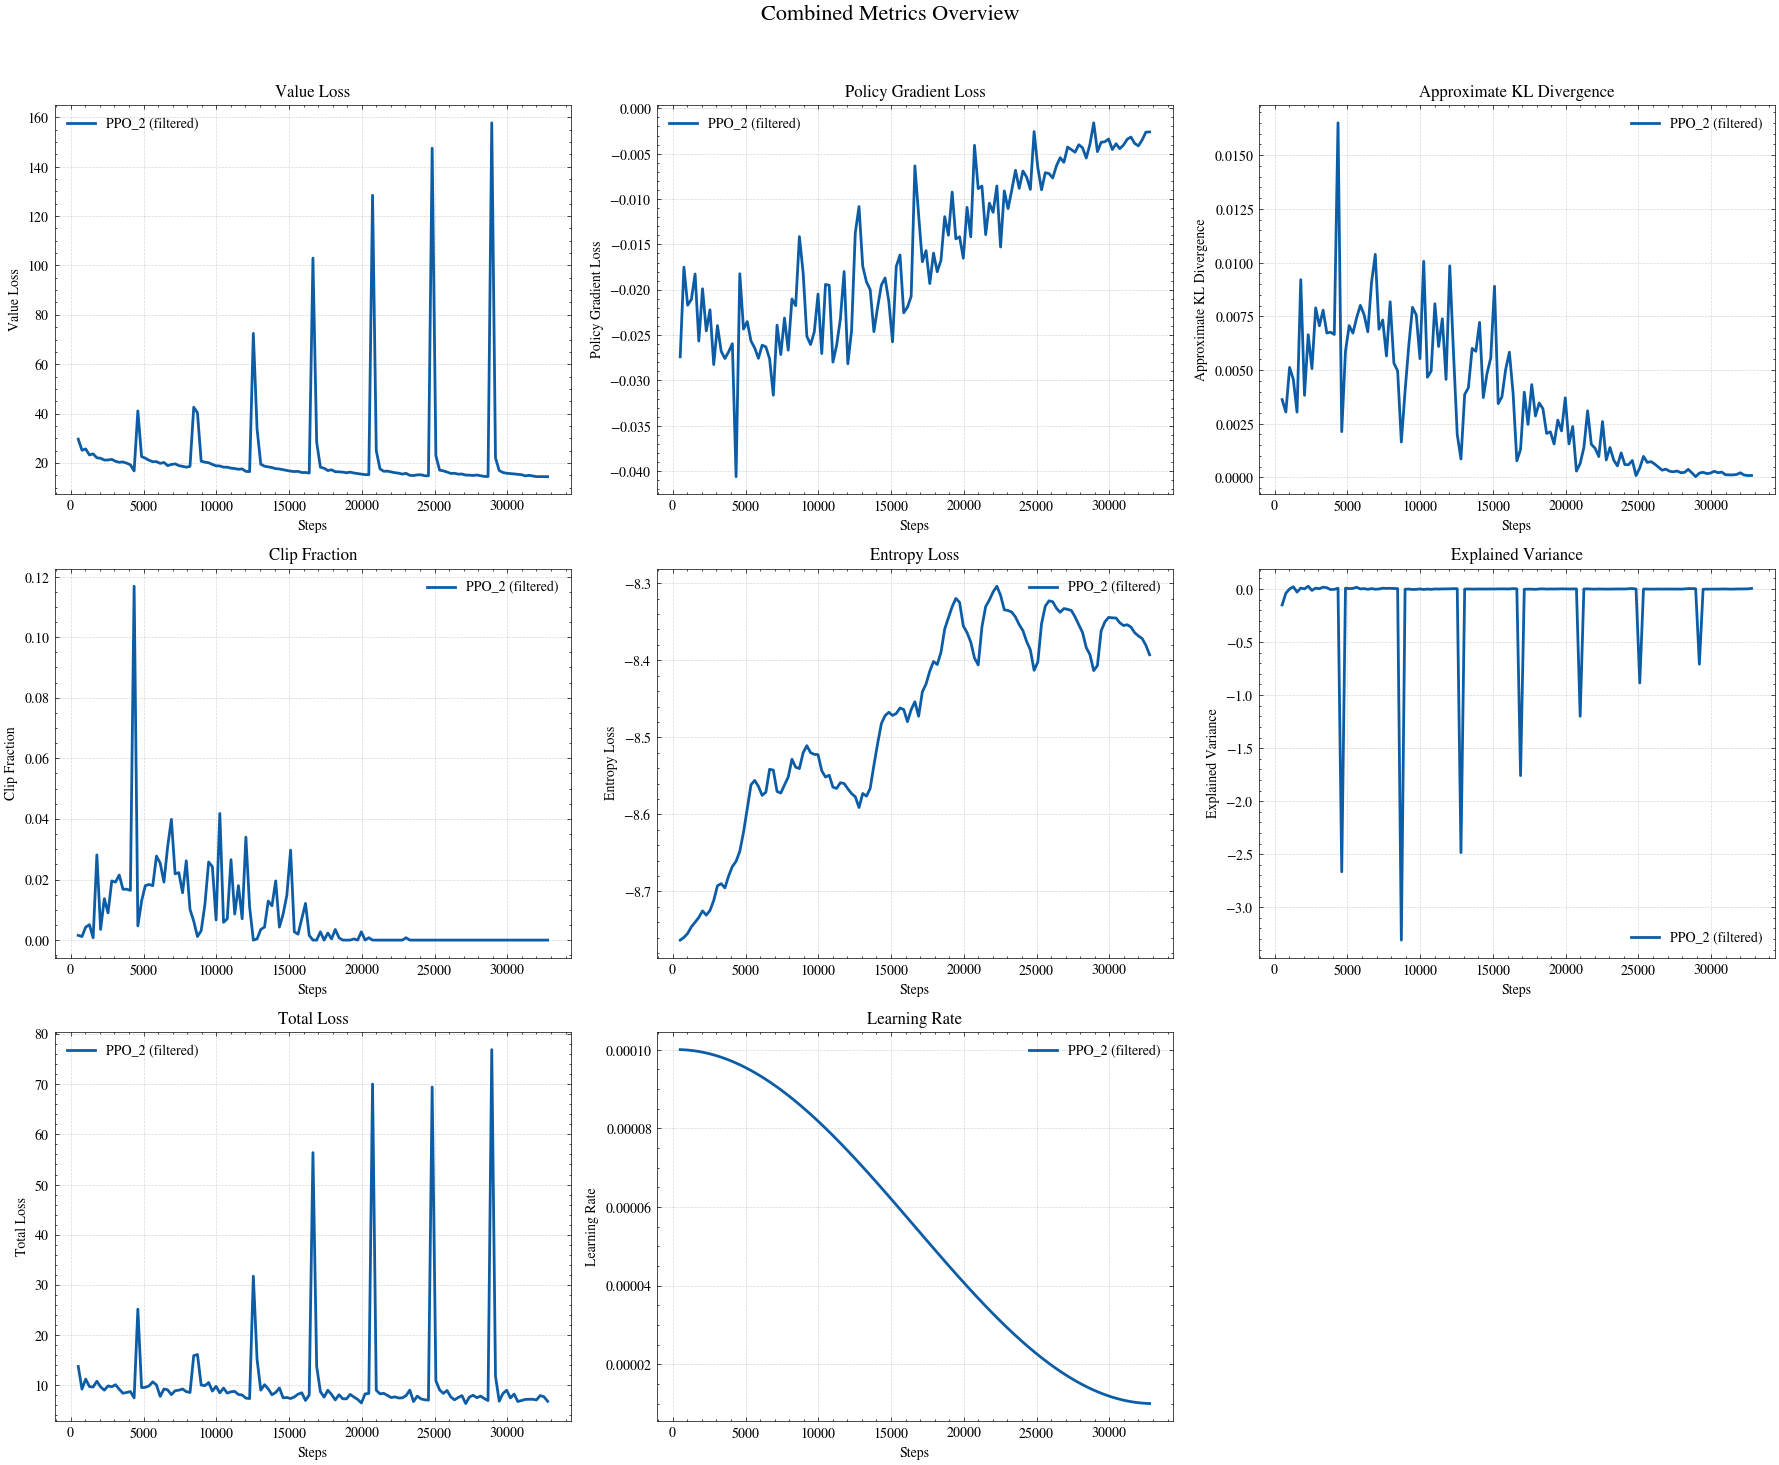

In [11]:
# Plot all selected metrics together in one combined figure
import math

num_metrics = len(metrics_to_plot)
cols = 3
rows = math.ceil(num_metrics / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), squeeze=False)
axes = axes.flatten()

for idx, (tag, title) in enumerate(metrics_to_plot):
    ax = axes[idx]
    plotted = False

    for run, scalars in all_scalars.items():
        if tag in scalars:
            steps = scalars[tag]['steps']
            values = scalars[tag]['values']
            filtered_values = smooth_series(values, smoothing_window)
            ax.plot(steps, filtered_values, label=f"{run} (filtered)", linewidth=2)
            plotted = True

    if not plotted:
        ax.text(0.5, 0.5, 'Tag not found', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.set_xlabel('Steps')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

for ax in axes[num_metrics:]:
    ax.axis('off')

fig.suptitle('Combined Metrics Overview', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
